In [ ]:
import os
%load_ext autoreload
%autoreload 2

In [1]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys

from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset

In [2]:
print(os.getcwd())

/Users/janyubhatt/Documents/Learning/Courses/OMSCS/crytpo_DLOB/notebooks


In [3]:
os.chdir('..')  # only need this temporily to get the right paths, change as needed
print(os.getcwd())

/Users/janyubhatt/Documents/Learning/Courses/OMSCS/crytpo_DLOB


In [6]:
# --- Configuration ---
# Cell 2: Define Configuration
# (Adjust paths and parameters as needed)
config = {
    'data_path': r'data/coinbase_book_2024-10-29_2024-11-11',
    'num_files': 1,
    'precision': np.float32,
    'clean_strategy': 'dropna',
    'num_levels_features': 10,
    'label_price_type': 'simple_midpoint',
    'label_price_levels': 1,
    'label_method': 'tlob',
    'label_k': 50,
    'label_h': 100,
    'label_alpha': 'auto', #'auto', # 0.0001, # Use dynamic or fixed alpha
    'verbose': True,
    'sequence_length': 100, # T
    'batch_size': 128,
    'split_fractions': {'train': 0.7, 'val': 0.15, 'test': 0.15},
    # 'output_path': '../data/processed/preprocessed_tlob_k50_h100_autoalpha.parquet' # Optional
}


In [5]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [7]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 228.70 MB
Shape before cleaning (dropna): (731123, 81)
NaN count before: 0
Shape after cleaning: (731123, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000116
Shape after label creation and NaN drop: (730973, 85)
Label distribution:
label
1    0.415705
2    0.293056
0    0.291239
Name: proportion, dtype: float64


0

In [8]:
df_processed.head()

,origin_time,b0,bq0,b1,bq1,b2,bq2,b3,bq3,b4,...,a17,aq17,a18,aq18,a19,aq19,mid_price,spread,vol_imbalance_10,label
50,2024-11-05 00:02:40.945852928,67828.171875,0.099000,67826.640625,0.041000,67824.687500,0.040000,67822.601562,0.057245,67822.593750,...,67842.898438,2.000000,67842.906250,0.736997,67844.062500,0.135550,67828.476562,3.671875,-0.636845,2
51,2024-11-05 00:02:43.496846848,67835.062500,0.119232,67834.437500,0.041000,67832.109375,0.040000,67830.453125,0.022114,67830.242188,...,67851.046875,0.577036,67851.789062,0.007379,67851.796875,0.221455,67836.234375,3.593750,-0.546378,2
52,2024-11-05 00:02:46.551655936,67835.062500,0.117270,67834.437500,0.041000,67832.109375,0.040000,67829.296875,0.050609,67829.281250,...,67849.796875,0.221073,67850.828125,0.736911,67851.000000,0.032948,67835.195312,1.515625,-0.438290,2
53,2024-11-05 00:02:53.896233984,67834.437500,0.109949,67828.187500,0.018934,67828.179688,0.041000,67828.039062,0.022115,67826.687500,...,67844.851562,0.090838,67846.437500,0.420753,67846.953125,0.032775,67831.328125,6.281250,-0.367076,2
54,2024-11-05 00:02:57.186903040,67828.367188,0.003000,67828.359375,0.010000,67828.351562,0.147999,67828.343750,0.124700,67828.273438,...,67846.437500,0.420753,67846.953125,0.032775,67849.281250,0.159408,67830.734375,4.742188,-0.453185,2


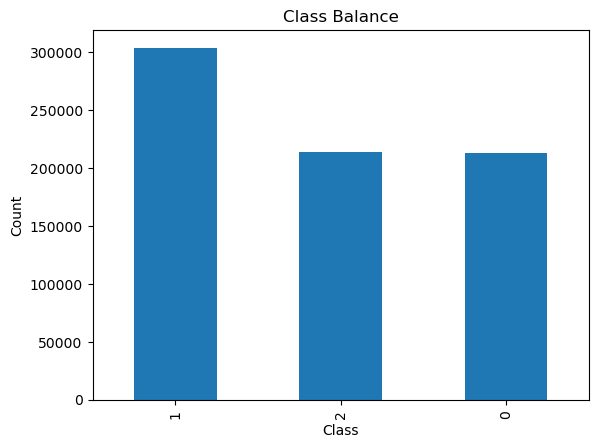

In [9]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [10]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config['split_fractions']['train'],
    val_frac=config['split_fractions']['val'],
    test_frac=config['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=511681, Val=109646, Test=109646


2999

In [11]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)

# Optional: Save the scaler object ('scaler') for later use on new data
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (83): ['b0', 'bq0', 'b1', 'bq1', 'b2', 'bq2', 'b3', 'bq3', 'b4', 'bq4']...
Normalization applied.


0

In [12]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].values

T = config['sequence_length']
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()


Sequence Creation Complete:
X_train_seq shape: (511581, 100, 83), y_train_seq shape: (511581,)
X_val_seq shape: (109546, 100, 83), y_val_seq shape: (109546,)
X_test_seq shape: (109546, 100, 83), y_test_seq shape: (109546,)


0

In [13]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True) # num_workers/pin_memory optional
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

print(f"\nDatasets and DataLoaders created.")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

# Now train_loader, val_loader, test_loader are ready for model training/evaluation
# You can optionally delete the large sequence numpy arrays now if memory is tight
# del X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq
# gc.collect()


Datasets and DataLoaders created.
Number of training batches: 3997
Number of validation batches: 856
Number of testing batches: 856
